In [21]:
import sys
import importlib
from collections import Counter
sys.path.append('../../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

IN_seq_path = '../MS1/IN/data/in.reduce4.seq'
PR_seq_path = '../MS1/PR/data/pr.exper.reduce4.seq'    
RT_seq_path = '../MS1/RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('../../MS1/IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('../../MS1/PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('../../MS1/RT/data/rt.reduce4.seq')

IN_consensus = '../../MS1/IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)


PR_consensus = '../../MS1/PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = '../../MS1/RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('../../MS1/IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('../../MS1/PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('../../MS1/RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('../../MS1/IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('../../MS1/PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('../../MS1/RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('../../MS1/IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('../../MS1/PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('../../MS1/RT/data/rt.fullseq')

IN_consensus_unreduced_seq = "".join(
    Counter(column).most_common(1)[0][0]
    for column in zip(*IN_all_seq_unreduced)
)
PR_consensus_unreduced_seq = "".join(
    Counter(column).most_common(1)[0][0]
    for column in zip(*PR_all_seq_unreduced)
)
RT_consensus_unreduced_seq = "".join(
    Counter(column).most_common(1)[0][0]
    for column in zip(*RT_all_seq_unreduced)
)

nl43_reduced = functions.read_seq('../../MS1/IN/data/in.nl43.reduce4.seq')[0]
nl43_unreduced = functions.reduced_to_unreduced_sequence(IN_redux, nl43_reduced, IN_all_seq_unreduced, start_index=1)
nl43_from_db = functions.read_seq('../../MS1/IN/data/in.nl43.seq')[0]

In [22]:
close_positions = [263, 142, 143, 144, 145, 146, 147, 148, 149, 151, 152, 153, 155, 51, 63, 64, 65, 66, 67, 92, 231, 116, 117, 118, 119, 120, 121]
sorted_close_positions = sorted(close_positions)

In [23]:
wt_IN = {}
for pos in range(1, 264):
    wt_IN[pos] = IN_consensus_seq[pos-1]
    

In [24]:
all_position_dEs = {}
all_position_pairs = []
close_positions_dEs = {}
close_positions_pairs = []
non_close_positions_dEs = {}
non_close_positions_pairs = []
for pos in range(1, 264):
    wt = wt_IN[pos]
    for aa in 'ABCD':
        if aa == wt:
            continue
        pair = f"{wt}{pos}{aa}"
        de = functions.calculate_delta_e(pair, IN_consensus_seq, IN_J, 1, 263)

        all_position_pairs.append(pair)
        all_position_dEs[pair] = de

        if pos in sorted_close_positions:
            close_positions_pairs.append(pair)
            close_positions_dEs[pair] = de
        else:
            non_close_positions_pairs.append(pair)
            non_close_positions_dEs[pair] = de



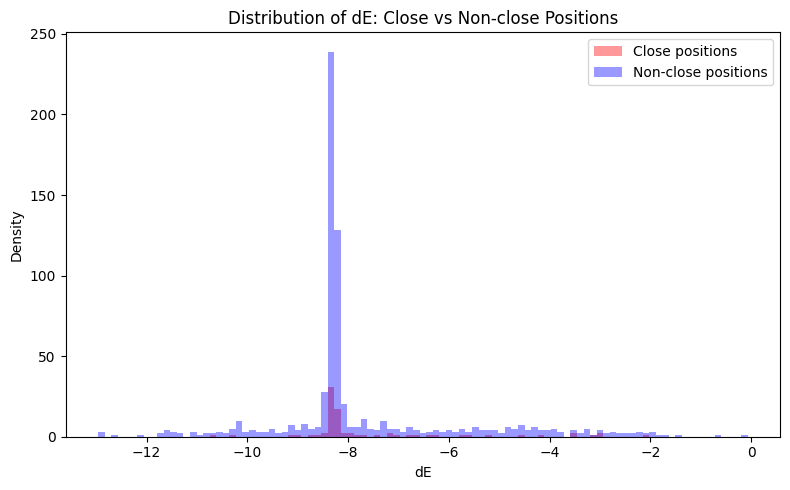

In [25]:
import numpy as np

import matplotlib.pyplot as plt

# Collect dE values
close_dEs = list(close_positions_dEs.values())
non_close_dEs = list(non_close_positions_dEs.values())

# Shared bins for fair comparison
all_dEs = close_dEs + non_close_dEs
bins = np.linspace(min(all_dEs), max(all_dEs), 100)
# bins = 100

plt.figure(figsize=(8, 5))
plt.hist(close_dEs, bins=bins, density=False, alpha=0.4, color='red', label='Close positions')
plt.hist(non_close_dEs, bins=bins, density=False, alpha=0.4, color='blue', label='Non-close positions')

plt.xlabel('dE')
plt.ylabel('Density')
plt.title('Distribution of dE: Close vs Non-close Positions')
plt.legend()
plt.tight_layout()
plt.show()

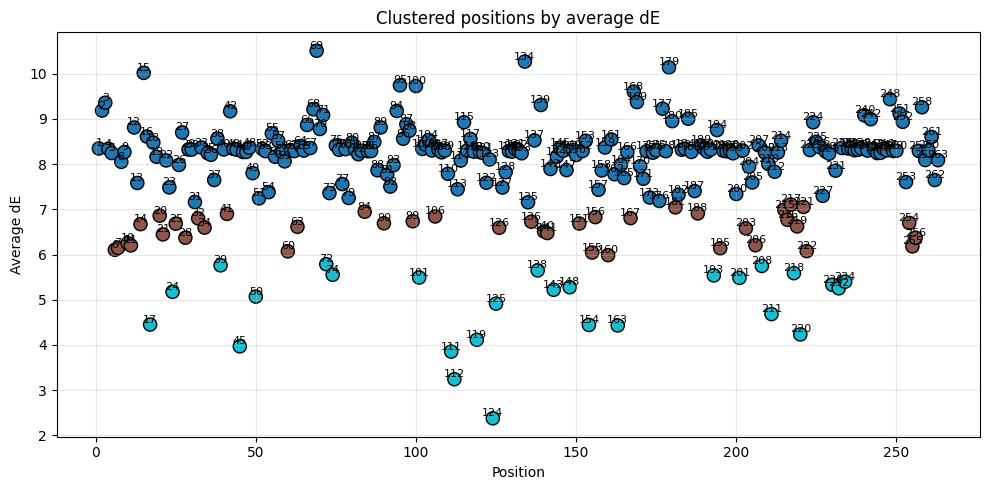

Saved to dE_average_data.txt


In [31]:
import re
from scipy.cluster.hierarchy import linkage, fcluster

# Compute average dE for each position
position_to_dEs = {}
for pair, de in all_position_dEs.items():
    pos = int(re.search(r"\d+", pair).group())
    position_to_dEs.setdefault(pos, []).append(float(de))

positions = sorted(position_to_dEs)
avg_dEs = np.array(np.sqrt([np.mean(position_to_dEs[p])**2 for p in positions]))
#rms = np.sqrt(np.mean(deltaE**2))
# Cluster positions using their average dE values
Z = linkage(avg_dEs.reshape(-1, 1), method="ward")
clusters = fcluster(Z, t=3, criterion="maxclust")

# Plot
plt.figure(figsize=(10, 5))
scatter = plt.scatter(positions, avg_dEs, c=clusters, cmap="tab10", s=90, edgecolor="k")

for p, y, c in zip(positions, avg_dEs, clusters):
    plt.text(p, y, str(p), fontsize=8, ha="center", va="bottom")

plt.xlabel("Position")
plt.ylabel("Average dE")
plt.title("Clustered positions by average dE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

output_path = "dE_average_data.txt"

with open(output_path, "w", encoding="utf-8") as f:
    f.write("position\tavg_dE\n")
    for p, de in zip(positions, avg_dEs):
        f.write(f"{p}\t{de:.6f}\n")

print(f"Saved to {output_path}")

In [30]:
from itertools import combinations

# Position range for IN based on redux mapping
min_position = min(pos for pos, _ in IN_redux.keys())
max_position = max(pos for pos, _ in IN_redux.keys())

# Build WT map from reduced IN consensus sequence
wt_IN = {
    pos: IN_consensus_seq[pos - min_position]
    for pos in range(min_position, max_position + 1)
}

alphabet = "ABCD"

# Build all single-mutation pairs: WT->MT (MT is one of the other 3 letters)
mutation_pairs = []
for pos in range(min_position, max_position + 1):
    wt = wt_IN[pos]
    for mt in alphabet:
        if mt != wt:
            mutation_pairs.append(f"{wt}{pos}{mt}")

# Compute all pairwise ddEs across single mutations (excluding same-position pairs)
output_path = "IN_all_pairs_ddE.txt"
total = 0

with open(output_path, "w", encoding="utf-8") as f:
    f.write("mutation_pair1\tmutation_pair2\tddE\n")
    for pair1, pair2 in combinations(mutation_pairs, 2):
        pos1 = int(pair1[1:-1])
        pos2 = int(pair2[1:-1])

        if pos1 == pos2:
            continue

        ddE = functions.calculate_dde_v2(
            pair1, pair2, IN_consensus_seq, IN_J, min_position, max_position
        )[3]

        f.write(f"{pair1}\t{pair2}\t{float(ddE):.6f}\n")
        total += 1

print(f"Saved {total} ddE pairs to {output_path}")

Saved 310077 ddE pairs to IN_all_pairs_ddE.txt
